In [1]:
import random
import numpy as np
import torch

def set_seed(seed_value):
    """Sets the seed for reproducibility."""
    random.seed(seed_value)
    np.random.seed(seed_value)
    torch.manual_seed(seed_value)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed_value)
        # The two lines below are for ensuring deterministic behavior on GPU
        # but can sometimes have a performance cost.
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

# Set the seed for your experiment
set_seed(42)

In [2]:
from pathlib import Path
import pickle
import sys
import os
sys.path.append('../')

DATA_DIR = Path('../data/100000_data_points')
DATA_PATH = DATA_DIR / "synthetic_rl_datasets.pkl"
try:
    with open(DATA_PATH, 'rb') as f:
        all_data = pickle.load(f)
except FileNotFoundError:
    print(f"File not found: {DATA_PATH}")
except Exception as e:
    print(f"Error loading dataset: {e}")


In [3]:
import random
import numpy as np
import sys
import torch
from tqdm import tqdm
import os
import matplotlib.pyplot as plt

sys.path.append('../')
# Add the root directory to the Python path to find your modules

from models.reward_cnn import RewardCNNCentralized
from tests.cnn.centralized.generate_synthetic_states import (
    generate_synthetic_state_at_most_1_apples,
)
from config import MODEL_DIR, GRAPHS_DIR
import torch
from tests.cnn.centralized.generate_synthetic_states import (
    generate_synthetic_state_at_most_1_apples,
)
from train_scripts.train_centralized_cnn import MODEL_SAVE_PATH
import matplotlib.pyplot as plt
from config import GRAPHS_DIR, OUT_DIR
from tqdm import tqdm




--- PyTorch is configured to use: cuda ---


In [ ]:
import json
import sys
sys.path.append('../')

from matplotlib.ticker import NullLocator, ScalarFormatter
from decentralized_helpers import generate_reward_vector, pick_agent_uniformly, get_agent_positions
from models.reward_cnn import RewardCNNDecentralized
# HERE AGENT 0 ALWAYS PICKS UP THE APPLE

# MLP experiments, 1 agent acting
NUM_ACTING_AGENTS = 1



In [5]:
# data class for neg1, 0, positive, all
from dataclasses import field
from dataclasses import dataclass


@dataclass
class ErrorData:
    neg1: list[float] = field(default_factory=list)
    zero: list[float] = field(default_factory=list)
    positive: list[float] = field(default_factory=list)
    all: list[float] = field(default_factory=list)

In [ ]:
import json

from numpy import dtype, float64, ndarray
from models.reward_cnn import RewardCNNDecentralized
from helpers.controllers import ViewController
from decentralized_helpers import generate_reward_vector, pick_agent_uniformly, get_agent_positions


accuracies = []

key = '6x6_2_agents'
hidden = 128
probabilities = [0.1, 0.3, 0.5, 0.7, 0.9]
accuracies = []
accuracies_when_reward_minus_1 = []
accuracies_when_reward_bigger_0 = []
accuracies_when_reward_0 = []
mae_overall_list = []
mae_neg1_list = []
mae_zero_list = []
mape_positive_list = [] # Using MAPE for positive rewards

# create all_errors with keys the probabilities
all_errors = {"0.1": ErrorData(), "0.3": ErrorData(), "0.5": ErrorData(), "0.7": ErrorData(), "0.9": ErrorData()}
mape_positive_list = [] # Using MAPE for positive rewards
for p_pick_apple in probabilities:
    print(f"--- probability: {p_pick_apple} ---")
    data = all_data[key]

    NUM_DATA_POINTS = 100000
    num_picks_apple = int(NUM_DATA_POINTS * p_pick_apple)
    num_no_picks_apple = NUM_DATA_POINTS - num_picks_apple

    data_with_apple = data['picks_apple'][:num_picks_apple]
    data_without_apple = data['doesnt_pick_apple'][:num_no_picks_apple]

    state_agentpos_reward = data_with_apple + data_without_apple
    set_seed(42)
    random.shuffle(state_agentpos_reward)
    # print(len(state_agentpos_reward))
    # print(state_agentpos_reward[0])

    NUM_TRAIN_EPISODES = 1000
    percent_train = 0.8
    total_train = int(0.8 * NUM_DATA_POINTS)
    state_agentpos_reward_TRAIN = state_agentpos_reward[:total_train]
    state_agentpos_reward_TEST = state_agentpos_reward[total_train:]
    if key == '6x6_2_agents':
        WIDTH = 6
        HEIGHT = 6
        NUM_AGENTS = 2
    elif key == '9x9_4_agents':
        WIDTH = 9
        HEIGHT = 9
        NUM_AGENTS = 4
    elif key == '12x12_7_agents':
        WIDTH = 12
        HEIGHT = 12
        NUM_AGENTS = 7
    else:
        raise ValueError(f"Unknown key: {key}")
    BATCH_SIZE = 32
    lr = 0.01

    NUM_ACTING_AGENTS = NUM_AGENTS

    # we use a list of networks instead of one
    networks = []

    for _ in range(NUM_AGENTS):
        networks.append(RewardCNNDecentralized(HEIGHT, WIDTH, lr, mlp_hidden_features=hidden))
    print(type(networks[0]))

    for i in tqdm(range(NUM_TRAIN_EPISODES), desc="Training"):
        for b in range(BATCH_SIZE):
            row_index = i * BATCH_SIZE + b

            # Pick the constant that represents how many acting agents we have. In the first setup, it's always agent with id 0.
            picker_id = pick_agent_uniformly(NUM_ACTING_AGENTS)

            assert(picker_id < NUM_ACTING_AGENTS)

            # We know that apple and agent are in the same cell if the apple is picked
            apple_pos = state_agentpos_reward_TRAIN[row_index]["agent_pos"]


            agent_positions = get_agent_positions(state_agentpos_reward_TRAIN[row_index]["state"]["agents"],
                                                    state_agentpos_reward_TRAIN[row_index]["agent_pos"], picker_id)

            picked =  state_agentpos_reward_TRAIN[row_index]["reward"] != 0

            assert np.array_equal(agent_positions[picker_id], apple_pos)
            reward_vector: ndarray[tuple[int], dtype[float64]] | ndarray[tuple[int, ...], dtype[float64]] = generate_reward_vector(picker_id, agent_positions, apple_pos, picked)
            if picked:
                assert(reward_vector[picker_id] == -1)
                sum_ = 0
                for r in reward_vector:
                    if r != -1:
                        sum_ += r

                # check with tolerance
                assert np.isclose(sum_, 2.0, atol=1e-8)
            else:
                assert(reward_vector[picker_id] == 0)

            state = state_agentpos_reward_TRAIN[row_index]["state"]

            for a in range(NUM_AGENTS):
                reward = reward_vector[a]
                reward_float = np.float32(reward)
                position = agent_positions[a]
                networks[a].add_experience_from_raw(state, reward, agent_pos=position)

        for model in networks:
            model.train_batch()

    model = networks[0]
    # print(f"Final loss after training: {model.loss_history[-1]}")

    # plot model loss
    # plt.figure(figsize=(8, 6))
    # plt.plot(model.loss_history)
    # plt.xlabel("Training Iterations")
    # plt.ylabel("Loss")
    # plt.title("Model Loss Over Time")
    # plt.savefig(GRAPHS_DIR / f"cnn_decentralized_loss_allActing_{key}_{hidden}h.png")

    ################## TESTING ##################
    num_test_episodes = len(state_agentpos_reward_TEST)
    num_correct = 0
    num_correct_when_reward_negative = 0
    num_correct_when_reward_0 = 0
    num_correct_when_reward_positive = 0
    num_negative_predictions = 0
    num_zero_predictions = 0
    num_positive_predictions = 0
    tol = 0.01 
    errors = []
    errors_reward_negative = []
    errors_reward_0 = []
    errors_reward_positive = []
    relative_errors_positive = [] 
    for i in tqdm(range(num_test_episodes), leave=False, desc="Testing"):
        picker_id = pick_agent_uniformly(NUM_ACTING_AGENTS)

        assert(picker_id < NUM_ACTING_AGENTS)

        # We know that apple and agent are in the same cell if the apple is picked
        apple_pos = state_agentpos_reward_TEST[i]["agent_pos"]

        agent_positions = get_agent_positions(state_agentpos_reward_TEST[i]["state"]["agents"],
                                                state_agentpos_reward_TEST[i]["agent_pos"], picker_id)

        picked =  state_agentpos_reward_TEST[i]["reward"] != 0 # BUG should be TEST not TRAIN

        assert np.array_equal(agent_positions[picker_id], apple_pos)
        reward_vector = generate_reward_vector(picker_id, agent_positions, apple_pos, picked)
        if picked:
            assert(reward_vector[picker_id] == -1)
            sum_ = 0
            for r in reward_vector:
                if r != -1:
                    sum_ += r
            # check with tolerance
            assert np.isclose(sum_, 2.0, atol=1e-8)
        else:
            assert(reward_vector[picker_id] == 0)

        state = state_agentpos_reward_TEST[i]["state"]
        a= 0 # only evaluate agent 0 for consistency
        reward = reward_vector[a]
        position = agent_positions[a]
        prediction = networks[a].get_model_reward_prediction_from_raw(state, agent_pos=position).item()
        error = abs(prediction - reward)
        errors.append(error)
        if reward == -1:
            errors_reward_negative.append(error)
            num_negative_predictions += 1
            if error < tol:
                    num_correct_when_reward_negative += 1
        elif reward == 0:
            errors_reward_0.append(error)
            num_zero_predictions += 1
            if error < tol:
                num_correct_when_reward_0 += 1
        elif reward > 0:
            errors_reward_positive.append(error)
            num_positive_predictions += 1
            relative_errors_positive.append(error / reward)
            if error < tol:
                num_correct_when_reward_positive += 1
        if error < tol:
            num_correct += 1
    all_errors[str(p_pick_apple)].all.extend(errors)
    all_errors[str(p_pick_apple)].neg1.extend(errors_reward_negative)
    all_errors[str(p_pick_apple)].zero.extend(errors_reward_0)
    all_errors[str(p_pick_apple)].positive.extend(errors_reward_positive)   

    accuracy = num_correct / (num_test_episodes * 1)
    accuracies.append(accuracy)
    accuracy_when_reward_minus_1 = num_correct_when_reward_negative / num_negative_predictions if num_negative_predictions > 0 else 0
    accuracies_when_reward_minus_1.append(accuracy_when_reward_minus_1)
    accuracy_when_reward_0 = num_correct_when_reward_0 / num_zero_predictions if num_zero_predictions > 0 else 0
    accuracies_when_reward_0.append(accuracy_when_reward_0)
    accuracy_when_reward_bigger_0 = num_correct_when_reward_positive / num_positive_predictions if num_positive_predictions > 0 else 0
    accuracies_when_reward_bigger_0.append(accuracy_when_reward_bigger_0)

    mape_positive = (np.mean(relative_errors_positive) * 100) if relative_errors_positive else 0
    mape_positive_list.append(mape_positive)
    
    # --- Append metrics for ERROR plot ---
    mae_overall_list.append(np.mean(errors) if errors else 0)
    mae_neg1_list.append(np.mean(errors_reward_negative) if errors_reward_negative else 0)
    mae_zero_list.append(np.mean(errors_reward_0) if errors_reward_0 else 0)


--- probability: 0.1 ---
<class 'models.reward_cnn.RewardCNNDecentralized'>


Training: 100%|██████████| 1000/1000 [00:08<00:00, 112.09it/s]


--- probability: 0.3 ---
<class 'models.reward_cnn.RewardCNNDecentralized'>


Training: 100%|██████████| 1000/1000 [00:08<00:00, 114.02it/s]


--- probability: 0.5 ---
<class 'models.reward_cnn.RewardCNNDecentralized'>


Training: 100%|██████████| 1000/1000 [00:09<00:00, 103.04it/s]


--- probability: 0.7 ---
<class 'models.reward_cnn.RewardCNNDecentralized'>


Training: 100%|██████████| 1000/1000 [00:11<00:00, 89.29it/s]


--- probability: 0.9 ---
<class 'models.reward_cnn.RewardCNNDecentralized'>


Training: 100%|██████████| 1000/1000 [00:12<00:00, 79.46it/s]


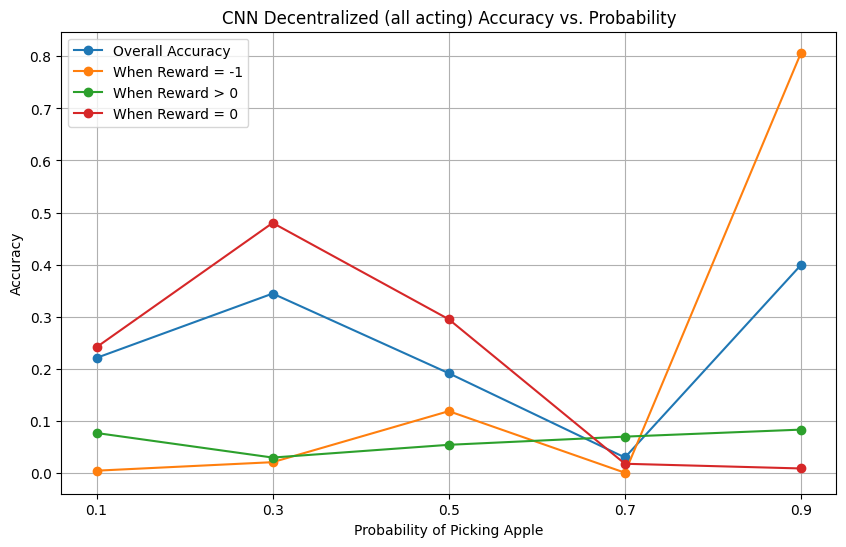

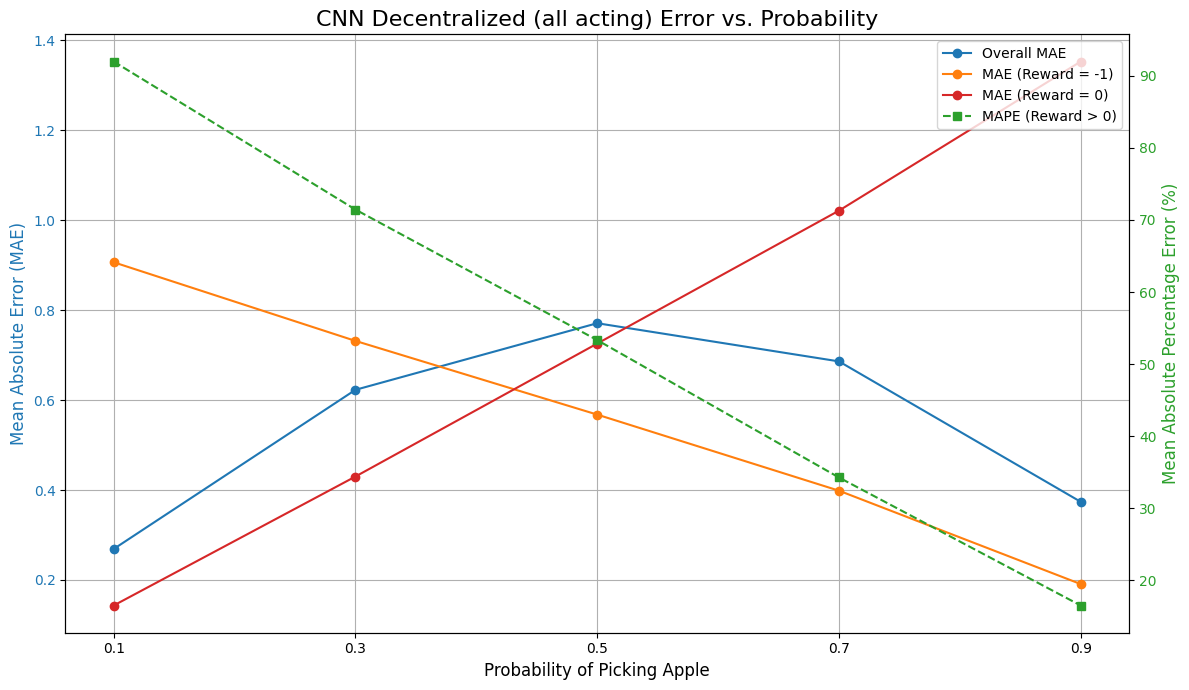

In [7]:


plt.figure(figsize=(10, 6))
plt.plot(probabilities, accuracies, marker="o", label="Overall Accuracy")
plt.plot(probabilities, accuracies_when_reward_minus_1, marker="o", label="When Reward = -1")
plt.plot(probabilities, accuracies_when_reward_bigger_0, marker="o", label="When Reward > 0")
plt.plot(probabilities, accuracies_when_reward_0, marker="o", label="When Reward = 0")
plt.xticks(probabilities)
plt.legend()
plt.xlabel("Probability of Picking Apple")
plt.ylabel("Accuracy")
plt.title("CNN Decentralized (all acting) Accuracy vs. Probability")
plt.grid(True)
ax = plt.gca()
ax.set_xticks(probabilities)
ax.xaxis.set_major_formatter(ScalarFormatter())

ax.xaxis.set_minor_locator(NullLocator())
plt.show()

# ====================================================================
# PLOT 2: ERROR (MAE / MAPE) VS. PROBABILITY (New Plot)
# ====================================================================
fig, ax1 = plt.subplots(figsize=(12, 7))

# Plot the MAE values on the primary (left) y-axis
ax1.plot(probabilities, mae_overall_list, marker="o", label="Overall MAE", color='tab:blue')
ax1.plot(probabilities, mae_neg1_list, marker="o", label="MAE (Reward = -1)", color='tab:orange')
ax1.plot(probabilities, mae_zero_list, marker="o", label="MAE (Reward = 0)", color='tab:red')
ax1.set_xlabel("Probability of Picking Apple", fontsize=12)
ax1.set_ylabel("Mean Absolute Error (MAE)", color='tab:blue', fontsize=12)
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.grid(True)

# Create a second y-axis for the MAPE values
ax2 = ax1.twinx()
ax2.plot(probabilities, mape_positive_list, marker="s", linestyle='--', label="MAPE (Reward > 0)", color='tab:green')
ax2.set_ylabel("Mean Absolute Percentage Error (%)", color='tab:green', fontsize=12)
ax2.tick_params(axis='y', labelcolor='tab:green')

# Combine legends from both axes for clarity
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='best')

plt.title("CNN Decentralized (all acting) Error vs. Probability", fontsize=16)
plt.xticks(probabilities)
fig.tight_layout()
plt.show()


In [12]:
print(mape_positive_list[3])

34.25873355833102


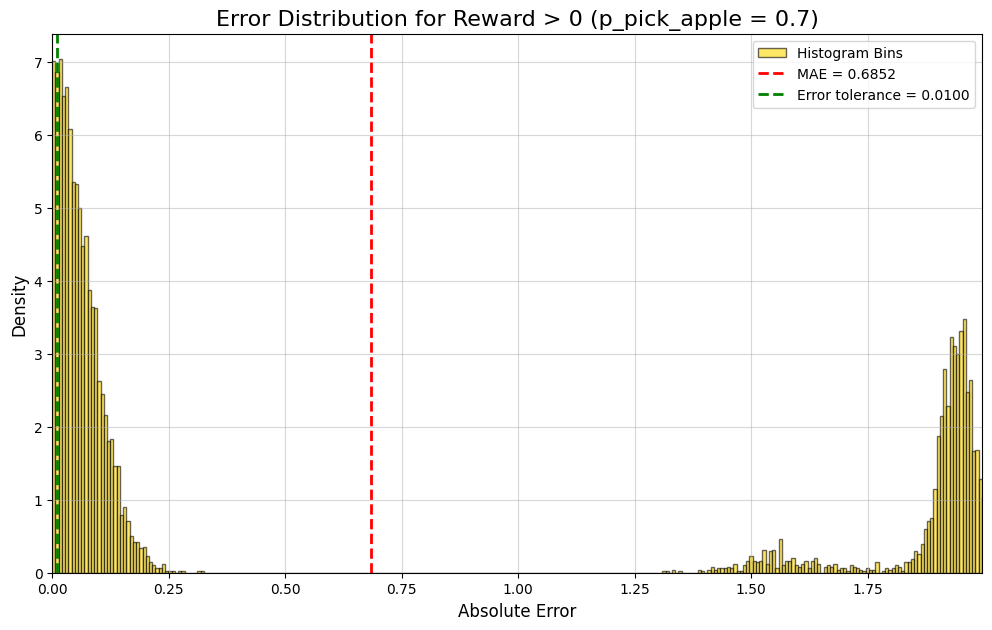

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# This code should be in a new cell, after your main loop has finished.

# Iterate through the populated all_errors dictionary
prob_key = '0.7'
error_data = all_errors[prob_key]

plt.figure(figsize=(12, 7))

# 1. Plot a fine-grained histogram
plt.hist(error_data.positive, bins=300, color='gold', edgecolor='black', alpha=0.6, density=True, label='Histogram Bins')

# 3. Add the MAE line for context
mae_pos = np.mean(error_data.positive)
plt.axvline(mae_pos, color='r', linestyle='dashed', linewidth=2, label=f'MAE = {mae_pos:.4f}')
plt.axvline(0.01, color='g', linestyle='dashed', linewidth=2, label=f'Error tolerance = {0.01:.4f}')

# --- Formatting ---
plt.title(f'Error Distribution for Reward > 0 (p_pick_apple = {prob_key})', fontsize=16)
plt.xlabel("Absolute Error", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.legend()
plt.grid(True, alpha=0.5)

# Zoom in to see the most important part of the distribution
plt.xlim(0, max(0.5, np.percentile(error_data.positive, 98))) # Zoom to the 98th percentile or 0.5, whichever is larger

plt.show()